In [2]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

In [3]:
class KalmanFilterLSTM:
    def __init__(self, model_path, sequence_length, input_features, p_loss=0.1):
        self.model = tf.keras.models.load_model(model_path)
        self.sequence_length = sequence_length
        self.input_features = input_features
        self.p_loss = p_loss  # Probability of GPS loss
        
        # Kalman filter parameters
        self.A = np.eye(2)  # State transition matrix
        self.H = np.eye(2)  # Observation matrix
        self.Q = np.eye(2) * 0.001  # Process noise covariance
        self.R = np.eye(2) * 0.01  # Measurement noise covariance (adjustable)
        self.I = np.eye(2)  # Identity matrix
        self.P = np.eye(2)  # Initial covariance matrix
        self.state = None  # Initial state (to be initialized dynamically)

    def predict(self, lstm_prediction):
        """
        Kalman Filter Prediction Step: Updates the state with LSTM's predicted deltas.
        """
        # Predict the next state based on the current state and LSTM deltas
        delta_lat, delta_lng = lstm_prediction
        self.state = np.array([[self.state[0, 0] + delta_lat], 
                               [self.state[1, 0] + delta_lng]])
        
        # Update covariance matrix
        self.P = self.A @ self.P @ self.A.T + self.Q  # Covariance prediction

    def update(self, measurement, use_lstm=False):
        """
        Kalman Filter Update Step: Corrects the prediction using either real GPS data or LSTM predictions.
        If use_lstm is True, LSTM predictions are treated as pseudo-measurements.
        """
        if use_lstm:
            # If using LSTM predictions, increase measurement noise to reflect lower confidence
            self.R = np.eye(2) * 0.05  # Adjust to a higher value to account for less reliable predictions
        else:
            # Regular GPS update with normal measurement noise
            self.R = np.eye(2) * 0.01

        # Measurement update step
        y = measurement - self.H @ self.state  # Measurement residual
        S = self.H @ self.P @ self.H.T + self.R  # Residual covariance
        K = self.P @ self.H.T @ np.linalg.inv(S)  # Kalman gain
        self.state = self.state + K @ y  # Updated state
        self.P = (self.I - K @ self.H) @ self.P  # Updated covariance matrix

    def calculate_routes(self, file_path):
        """
        Main function to calculate the real and predicted routes using the Kalman filter and LSTM.
        Randomly simulates GPS signal loss based on the probability p_loss.
        """
        data = pd.read_csv(file_path, delimiter=";")
        
        # Get the first point from 'Lat' and 'Lng'
        lng_real = [data.iloc[0]['Lng']]
        lat_real = [data.iloc[0]['Lat']]

        # Initialize real route
        for i in range(1, len(data)):
            delta_lng = data.iloc[i]['delta_Lng']
            delta_lat = data.iloc[i]['delta_Lat']
            lng_real.append(lng_real[-1] + delta_lng)
            lat_real.append(lat_real[-1] + delta_lat)

        # Now calculate the predicted route with Kalman filter correction
        lng_pred = [data.iloc[0]['Lng']]
        lat_pred = [data.iloc[0]['Lat']]

        # Extract input data for LSTM predictions
        input_data = data[self.input_features].values

        # Initialize Kalman filter state with the first GPS position
        self.state = np.array([[lat_pred[0]], [lng_pred[0]]])

        for i in range(1, len(data)):
            # Prepare input sequence for LSTM prediction
            if i >= self.sequence_length:
                X_test = input_data[i - self.sequence_length:i].reshape(1, self.sequence_length, len(self.input_features))
                delta_lng_pred, delta_lat_pred = self.model.predict(X_test, verbose=0)[0] / 1000  # Verbose set to 0 to suppress output

                # Predict the next state using Kalman filter
                self.predict([delta_lat_pred, delta_lng_pred])

                # Simulate GPS loss using np.random.rand()
                if np.random.rand() > self.p_loss:
                    # Apply Kalman filter correction with real GPS data (if available)
                    measurement = np.array([data.iloc[i]['Lat'], data.iloc[i]['Lng']]).reshape(-1, 1)
                    self.update(measurement)
                else:
                    # Apply Kalman filter correction with LSTM predictions as pseudo-measurements
                    measurement = np.array([delta_lat_pred, delta_lng_pred]).reshape(-1, 1)
                    self.update(measurement, use_lstm=True)
                
                # Store the predicted lat/lng
                lng_pred.append(self.state[1, 0])
                lat_pred.append(self.state[0, 0])
            else:
                # For the first few rows, use the real data
                lng_pred.append(lng_real[i])
                lat_pred.append(lat_real[i])

        return lat_real, lng_real, lat_pred, lng_pred

    def plot_routes(self, lat_real, lng_real, lat_pred, lng_pred, file_path):
        """
        Plots the real and predicted routes.
        """
        plt.figure(figsize=(10, 6))
        plt.plot(lng_real, lat_real, 'bo-', label='Real Route', linewidth=2)
        plt.plot(lng_pred, lat_pred, 'ro--', label='Predicted Route (Kalman)', linewidth=2)
        plt.title('Kalman Filtered Path vs Real GPS Data with Random GPS Loss Simulation for file {}'.format(file_path))
        plt.xlabel('Longitude')
        plt.ylabel('Latitude')
        plt.legend(loc='best')
        plt.grid(True)
        plt.show()


In [4]:
sequence_length = 20
input_features = ['Acc_X', 'Acc_Y', 'Acc_Z', 'Gyro_X', 'Gyro_Y', 'Gyro_Z', 'Tilt_X', 'Tilt_Y', 'Tilt_Z', 'Mag_X', 'Mag_Y', 'Mag_Z', 'Head', 'Temp', 'Press', 'delta_Alt']

test_folder_path = 'data/test'
models_folder = 'models'

model_name = 'lstm_delta_gps_model.keras'

model_path = os.path.join(models_folder, model_name)

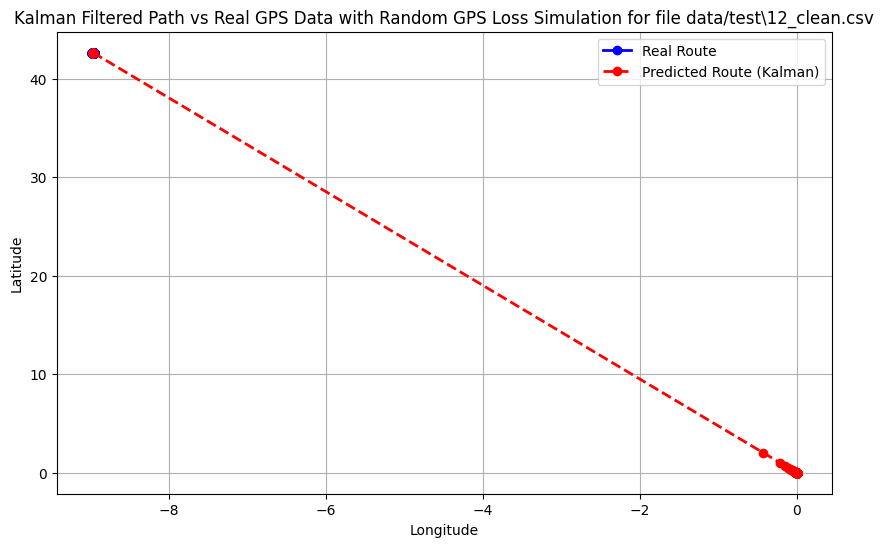

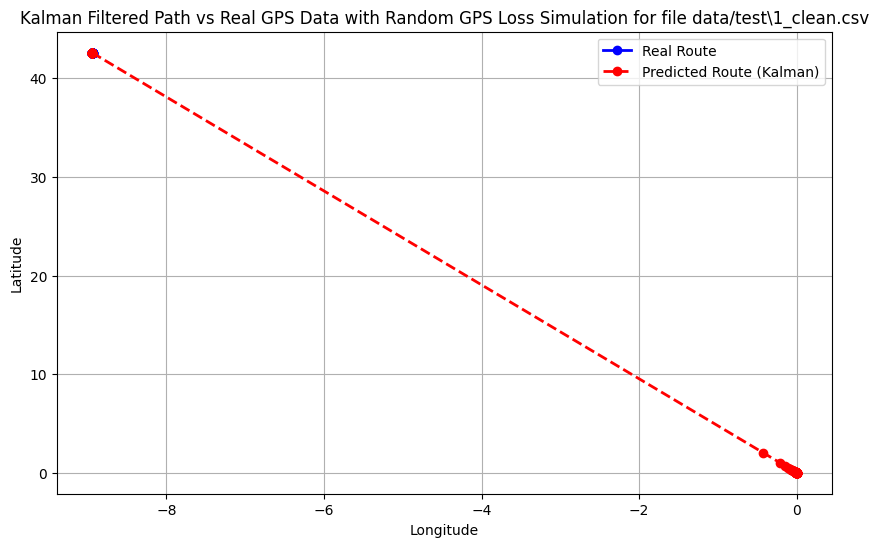

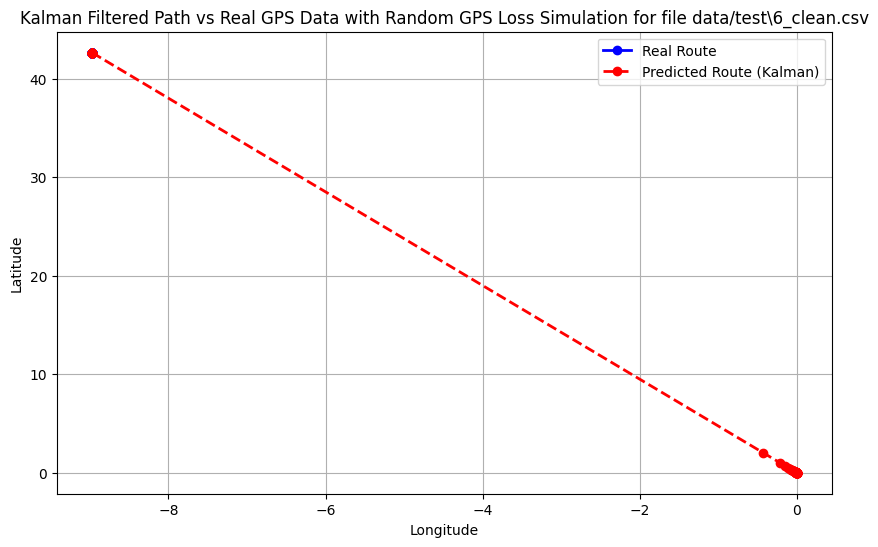

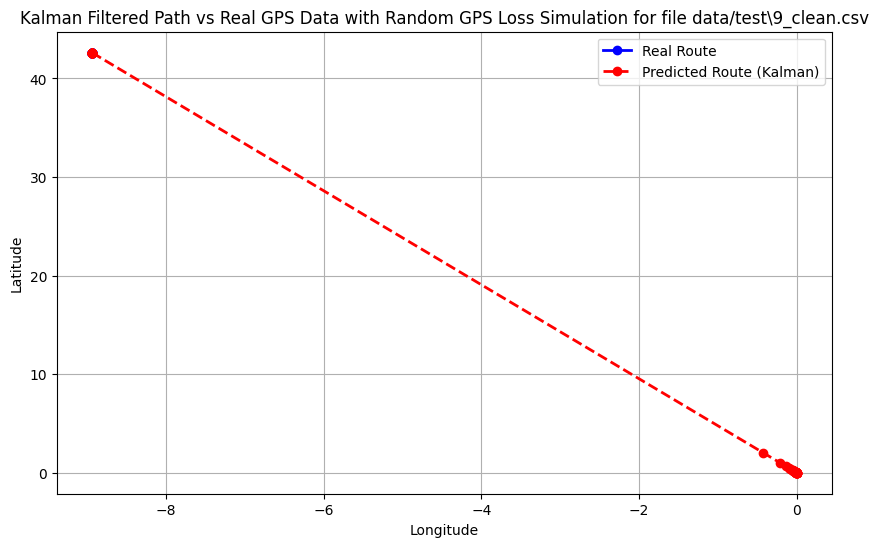

In [5]:
p_loss = 1

for file in os.listdir(test_folder_path):
    file_path = os.path.join(test_folder_path, file)
    # Calculate routes using the Kalman filter and LSTM
    kf_lstm = KalmanFilterLSTM(model_path, sequence_length, input_features, p_loss)
    lat_real, lng_real, lat_pred, lng_pred = kf_lstm.calculate_routes(file_path)
    # Plot the results
    kf_lstm.plot_routes(lat_real, lng_real, lat_pred, lng_pred, file_path)